In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [25]:
df = pd.read_csv(r"C:\Users\Ragav\Desktop\Nimblix Technology\4 Mar House Price Data\House Price Prediction Dataset.csv")

In [26]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [28]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [29]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [30]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [31]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

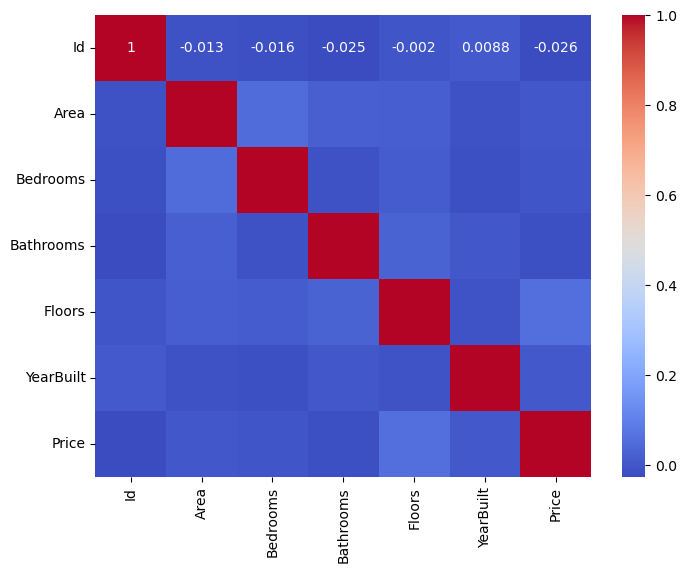

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

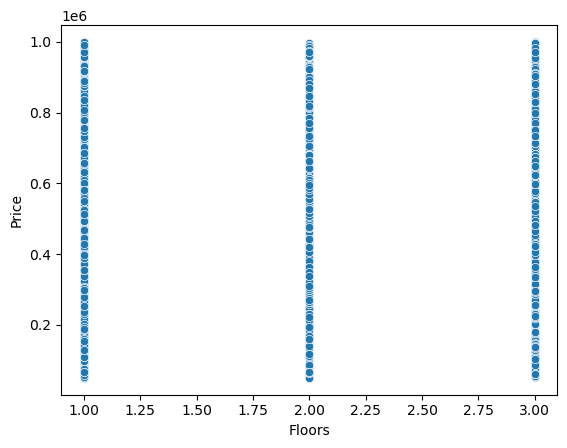

In [46]:
sns.scatterplot(x=df['Floors'], y=df['Price'])
plt.show()

In [70]:
df = df.drop("Id", axis=1)

In [71]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Price,Location_Rural,Location_Suburban,Location_Urban
0,1360,5,4,3,1970,Excellent,No,149919,False,False,False
1,4272,5,4,3,1958,Excellent,No,424998,False,False,False
2,3592,2,2,3,1938,Good,No,266746,False,False,False
3,966,4,2,2,1902,Fair,Yes,244020,False,True,False
4,4926,1,4,2,1975,Fair,Yes,636056,False,False,False


In [57]:
X = df[['Bathrooms', 'Bedrooms','Area']]
y = df['Price']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head()

,Actual Price,Predicted Price
1860,514764,522171.740628
353,694256,551143.219174
1333,66375,522026.632254
905,650243,551321.926057
1289,223285,541453.788988


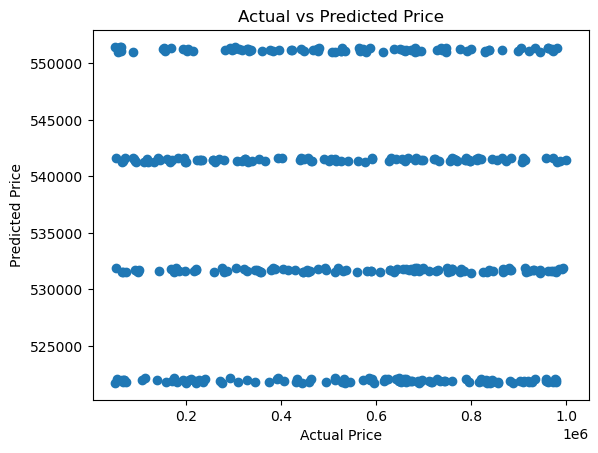

In [63]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [72]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.008248471565956317
